ILP in Real Time Scheduling: Traffic Management for Autonomous Vehicles
Ekene Okeke and Kadhana Penumaka

In [1]:
!pip install numpy pandas matplotlib pulp

In [2]:
#import statements
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pulp import LpProblem, LpMinimize, LpVariable, lpSum, LpStatus, value

In [3]:
# This will help to reproduce the same vehicles in every run
random.seed(42)
np.random.seed(42)

# Parameters
intersection_length = 10 
n_vehicles = 9
v_avg_mean = 5 
v_avg_std = 0.5 

# Generate random vehicles' average speeds
v_avgs = np.clip(np.random.normal(v_avg_mean, v_avg_std, n_vehicles), 1, None)

# Calculate desired access time
desired_access_times = intersection_length / v_avgs

# Vehicle IDs
vehicle_ids = list(range(1, n_vehicles + 1))

# Create DataFrame
vehicles_df = pd.DataFrame({"vehicle_id": vehicle_ids,"v_avg": v_avgs,"desired_access_time": desired_access_times})

print("\nVehicles that have been randomly generated are as follows:")
print(vehicles_df)


Vehicles that have been randomly generated are as follows:
   vehicle_id     v_avg  desired_access_time
0           1  5.248357             1.905358
1           2  4.930868             2.028041
2           3  5.323844             1.878342
3           4  5.761515             1.735655
4           5  4.882923             2.047954
5           6  4.882932             2.047950
6           7  5.789606             1.727233
7           8  5.383717             1.857453
8           9  4.765263             2.098520


In [4]:
# Build MILP
prob = LpProblem("Access_Time_Optimization", LpMinimize)

# T_access
t_access = {vid: LpVariable(f"t_access_{vid}", lowBound=0) for vid in vehicle_ids}

# Entry and Exit times
t_enter = {vid: t_access[vid] for vid in vehicle_ids}  # Enter time = access time
t_exit = {vid: LpVariable(f"t_exit_{vid}", lowBound=0) for vid in vehicle_ids}

# Constraints for exit times
for vid in vehicle_ids:
    prob += t_exit[vid] == t_access[vid] + (intersection_length / v_avgs[vid - 1]), f"ExitTimeConstraint_{vid}"

# Constraints
for i in range(2, n_vehicles + 1):
    prob += t_access[i] >= t_access[i-1], f"OrderConstraint_{i}"

# Objective weights
w1 = 1.0
w2 = 1.0

# Cost function terms
# J1: Total access time spread
J1 = t_access[max(vehicle_ids)] - t_access[min(vehicle_ids)]

# Delta variables for absolute difference modeling
delta = {vid: LpVariable(f"delta_{vid}", lowBound=0) for vid in vehicle_ids}

# Constraints for delta (modeling absolute value)
for vid in vehicle_ids:
    prob += t_access[vid] - desired_access_times[vid - 1] <= delta[vid], f"DeltaUpper_{vid}"
    prob += desired_access_times[vid - 1] - t_access[vid] <= delta[vid], f"DeltaLower_{vid}"

# J2: Sum of deltas
J2 = lpSum(delta.values())

# Full Objective Function
prob += w1 * J1 + w2 * J2, "TotalCost"

# Solve
status = prob.solve()

print(f"\nSolved Milp problem status: {LpStatus[status]}")


Solved Milp problem status: Optimal


In [5]:
# Extract the optimized access, enter, and exit times
optimized_access_times = [value(t_access[vid]) for vid in vehicle_ids]
optimized_enter_times = optimized_access_times  # Enter time = access time
optimized_exit_times = [value(t_exit[vid]) for vid in vehicle_ids]

# Final DataFrame
final_df = vehicles_df.copy()
final_df["optimized_access_time"] = optimized_access_times
final_df["difference"] = final_df["optimized_access_time"] - final_df["desired_access_time"]
final_df["optimized_enter_time"] = optimized_enter_times
final_df["optimized_exit_time"] = optimized_exit_times

print("\nFinal Access Times is as folows:")
print(final_df)


Final Access Times is as folows:
   vehicle_id     v_avg  desired_access_time  optimized_access_time  \
0           1  5.248357             1.905358               1.905358   
1           2  4.930868             2.028041               1.905358   
2           3  5.323844             1.878342               1.905358   
3           4  5.761515             1.735655               1.905358   
4           5  4.882923             2.047954               1.905358   
5           6  4.882932             2.047950               1.905358   
6           7  5.789606             1.727233               1.905358   
7           8  5.383717             1.857453               1.905358   
8           9  4.765263             2.098520               2.098520   

     difference  optimized_enter_time  optimized_exit_time  
0  3.663013e-08              1.905358             3.810716  
1 -1.226824e-01              1.905358             3.933399  
2  2.701625e-02              1.905358             3.783700  
3  1.697036

Line graph is as follows

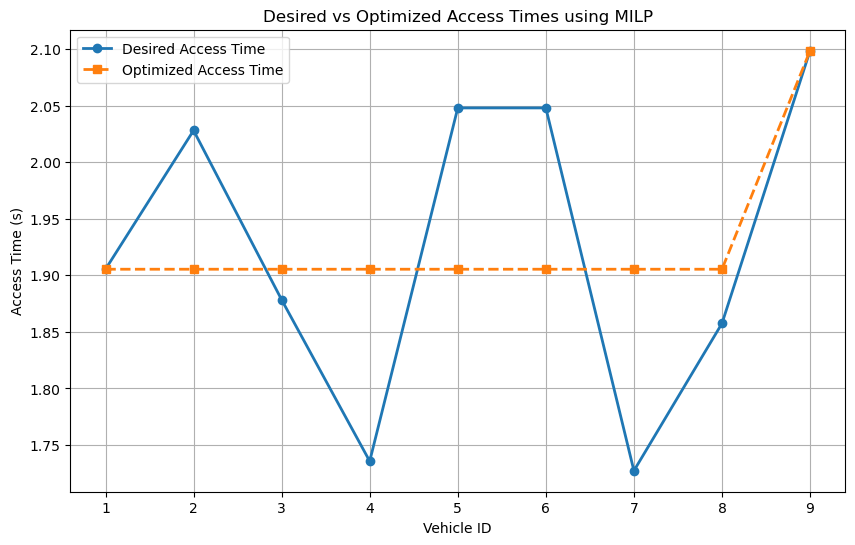

In [6]:
# Line graph that shoes desired access time vs milp access time
plt.figure(figsize=(10, 6))
plt.plot(vehicle_ids, desired_access_times, 'o-', label="Desired Access Time", linewidth=2)
plt.plot(vehicle_ids, optimized_access_times, 's--', label="Optimized Access Time", linewidth=2)
plt.xlabel("Vehicle ID")
plt.ylabel("Access Time (s)")
plt.title("Desired vs Optimized Access Times using MILP")
plt.legend()
plt.grid(True)
plt.show()

Difference graph is as follows:

In [ ]:
# Line graph of differences between the Optimized with MILP and Desired Access time
plt.figure(figsize=(10, 6))
plt.plot(vehicle_ids, final_df["difference"], 'd-', color="red", linewidth=2)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Vehicle ID")
plt.ylabel("Access Time Difference (MILP Optimized - Desired) (s)")
plt.title("Difference between MILPOptimized and Desired Access Times")
plt.grid(True)
plt.show()


Barchart:

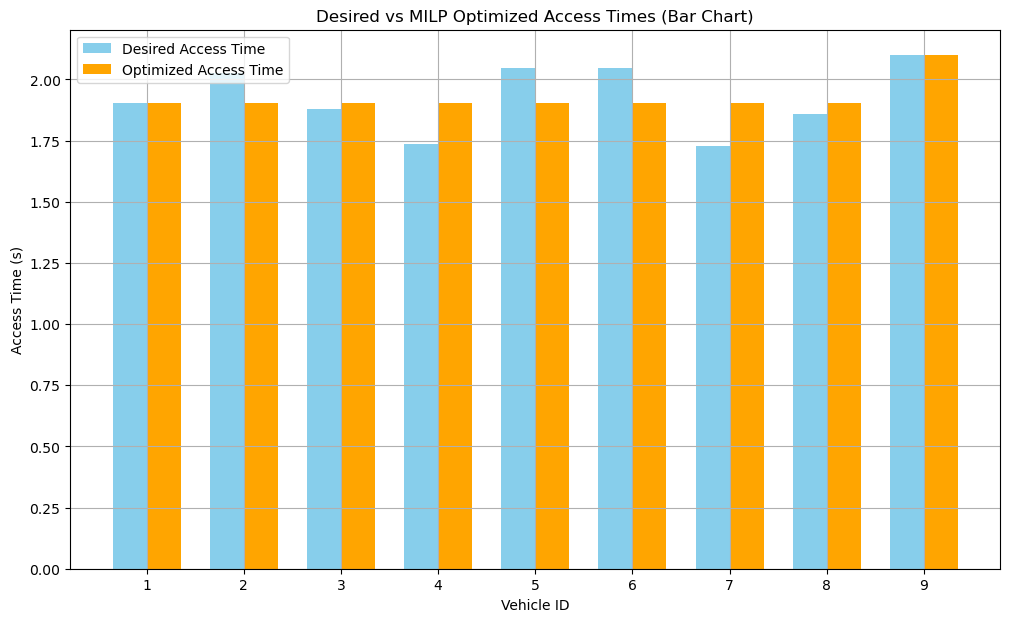

In [7]:
# Bar Chart
width = 0.35
x = np.arange(n_vehicles)

plt.figure(figsize=(12, 7))
plt.bar(x - width/2, desired_access_times, width=width, label='Desired Access Time', color='skyblue')
plt.bar(x + width/2, optimized_access_times, width=width, label='Optimized Access Time', color='orange')
plt.xlabel('Vehicle ID')
plt.ylabel('Access Time (s)')
plt.title('Desired vs MILP Optimized Access Times (Bar Chart)')
plt.xticks(x, vehicle_ids)
plt.legend()
plt.grid(True)
plt.show()